# Sentiment Analysis of Financial News using RNN, LSTM, and Word2Vec Embeddings

### Name:Bandana Yadav
### University ID:2408186
### Dataset: Financial Phrase Dataset (4840 sentences, 3 sentiment classes)

## Part 3: Natural Language Processing Task
### This notebook presents a complete NLP workflow for classifying the sentiment of financial news statements into positive, neutral, and negative classes. The project develops and evaluates three different deep learning approaches:

#### Model 1: Simple RNN using a trainable Embedding layer
#### Model 2: LSTM model with a trainable Embedding layer
#### Model 3: LSTM model utilizing pretrained GloVe embeddings (Word2Vec-like representations)

## 1. Imports

In [8]:
!pip install contractions gensim -q

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import re
import string
import contractions
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from gensim.models import Word2Vec

import gensim.downloader as api

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")

Libraries imported successfully!
TensorFlow Version: 2.20.0


## 2. Load and Explore the Dataset

In [9]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/NLP/3. Financial Phrase Dataset/financial_phrase.csv')
df.columns = ['text', 'label']

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (2264, 2)

First 5 rows:


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
print("=== Financial News Sentiment Dataset Overview ===")

print(f"Total news samples      : {len(df)}")
print(f"Duplicate text entries  : {df.duplicated(subset='text').sum()}")
print(f"Missing values          :\n{df.isnull().sum()}")

print("\nSentiment Label Distribution:")
print(df['label'].value_counts())

print("\nSentiment Label Proportions:")
print(df['label'].value_counts(normalize=True).round(3))

=== Financial News Sentiment Dataset Overview ===
Total news samples      : 2264
Duplicate text entries  : 5
Missing values          :
text     0
label    0
dtype: int64

Sentiment Label Distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Sentiment Label Proportions:
label
neutral     0.614
positive    0.252
negative    0.134
Name: proportion, dtype: float64


After removing duplicates: 2259 samples


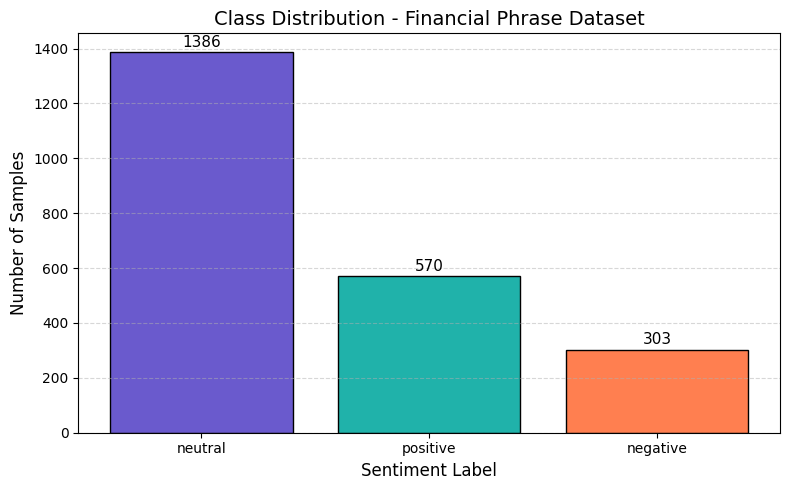

In [12]:
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f"After removing duplicates: {len(df)} samples")

label_counts = df['label'].value_counts()

colors = ['#6A5ACD', '#20B2AA', '#FF7F50']

plt.figure(figsize=(8, 5))

bars = plt.bar(
    label_counts.index,
    label_counts.values,
    color=colors,
    edgecolor='black'
)

plt.title('Class Distribution - Financial Phrase Dataset', fontsize=14)
plt.xlabel('Sentiment Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        height + 10,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

News Text Length Statistics:
count    2259.00
mean       22.43
std        10.12
min         2.00
25%        15.00
50%        21.00
75%        28.00
max        81.00
Name: news_length, dtype: float64

Text Length Statistics by Sentiment:
           count   mean    std  min   25%   50%   75%   max
label                                                      
negative   303.0  24.80  10.28  5.0  17.0  22.0  30.0  56.0
neutral   1386.0  20.91   9.64  2.0  14.0  19.0  26.0  81.0
positive   570.0  24.88  10.48  6.0  17.0  23.0  31.0  57.0


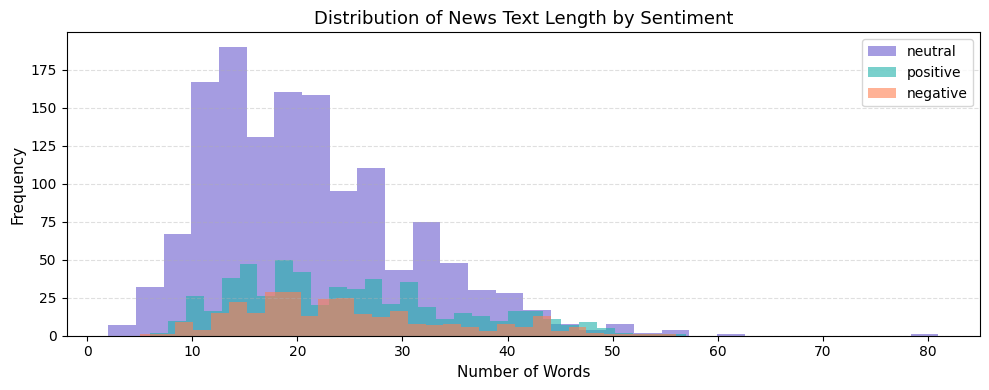

In [13]:
df['news_length'] = df['text'].apply(lambda sentence: len(sentence.split()))

print("News Text Length Statistics:")
print(df['news_length'].describe().round(2))

print("\nText Length Statistics by Sentiment:")
print(df.groupby('label')['news_length'].describe().round(2))

plt.figure(figsize=(10, 4))

sentiment_palette = {
    'neutral': '#6A5ACD',
    'positive': '#20B2AA',
    'negative': '#FF7F50'
}

for sentiment in df['label'].unique():
    text_subset = df[df['label'] == sentiment]['news_length']

    plt.hist(
        text_subset,
        bins=30,
        alpha=0.6,
        label=sentiment,
        color=sentiment_palette[sentiment]
    )

plt.title('Distribution of News Text Length by Sentiment', fontsize=13)
plt.xlabel('Number of Words', fontsize=11)
plt.ylabel('Frequency', fontsize=11)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 3. Text Preprocessing, Tokenization, and Sequence Padding

In [14]:
# Load English stopwords and initialize lemmatizer
stop_words_set = set(stopwords.words('english'))
word_lemmatizer = WordNetLemmatizer()

def preprocess_financial_text(news_text):
    # Fix contractions (e.g., don't → do not)
    news_text = contractions.fix(news_text)

    # Convert all text to lowercase for consistency
    news_text = news_text.lower()

    # Remove URLs from text
    news_text = re.sub(r'http\S+|www\S+', '', news_text)

    # Remove mentions (@user) and hashtags (#topic)
    news_text = re.sub(r'@\w+|#\w+', '', news_text)

    # Remove numbers
    news_text = re.sub(r'\d+', '', news_text)

    # Keep only alphabets and spaces (remove punctuation/special characters)
    news_text = re.sub(r'[^a-z\s]', '', news_text)

    # Remove extra whitespace
    news_text = re.sub(r'\s+', ' ', news_text).strip()

    token_list = []

    # Tokenize text and process each word
    for token in news_text.split():
        # Remove stopwords and very short tokens
        if token not in stop_words_set and len(token) > 1:
            # Lemmatize word (convert to base form)
            token_list.append(word_lemmatizer.lemmatize(token))

    # Join tokens back into a cleaned sentence
    return ' '.join(token_list)

# Apply preprocessing to dataset
df['processed_text'] = df['text'].apply(preprocess_financial_text)

# Show sample comparison between original and cleaned text
print("Sample comparison after preprocessing:\n")

for idx in range(3):
    print(f"Original News  : {df['text'].iloc[idx]}")
    print(f"Processed News : {df['processed_text'].iloc[idx]}")
    print(f"Label          : {df['label'].iloc[idx]}\n")

Sample comparison after preprocessing:

Original News  : According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Processed News : according gran company plan move production russia although company growing
Label          : neutral

Original News  : For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .
Processed News : last quarter componenta net sale doubled eurm eurm period year earlier moved zero pretax profit pretax loss eurm
Label          : positive

Original News  : In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .
Processed News : third quarter net sale increased eur mn operating profit eur mn
Label          : positive



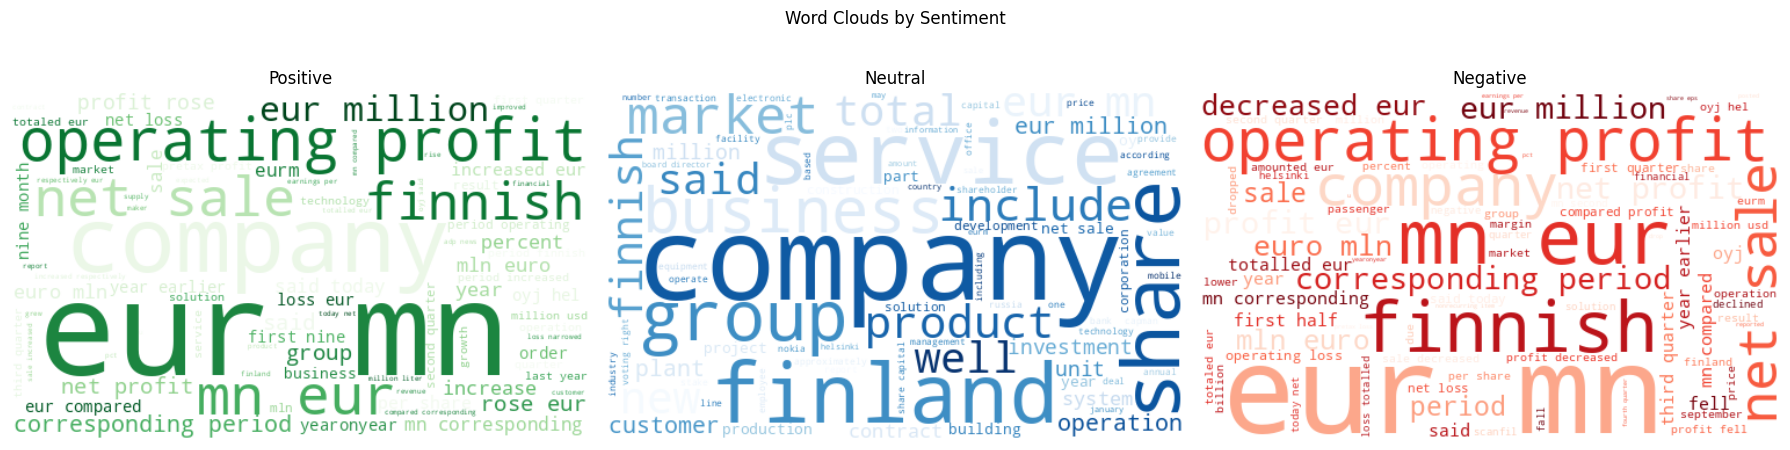

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

wc_colors = {
    'positive': 'Greens',
    'neutral': 'Blues',
    'negative': 'Reds'
}

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    text_data = ' '.join(df[df['label'] == sentiment]['processed_text'])

    wc = WordCloud(
        width=500,
        height=300,
        background_color='white',
        colormap=wc_colors[sentiment],
        max_words=80
    ).generate(text_data)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sentiment.capitalize())
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment')
plt.tight_layout()
plt.show()

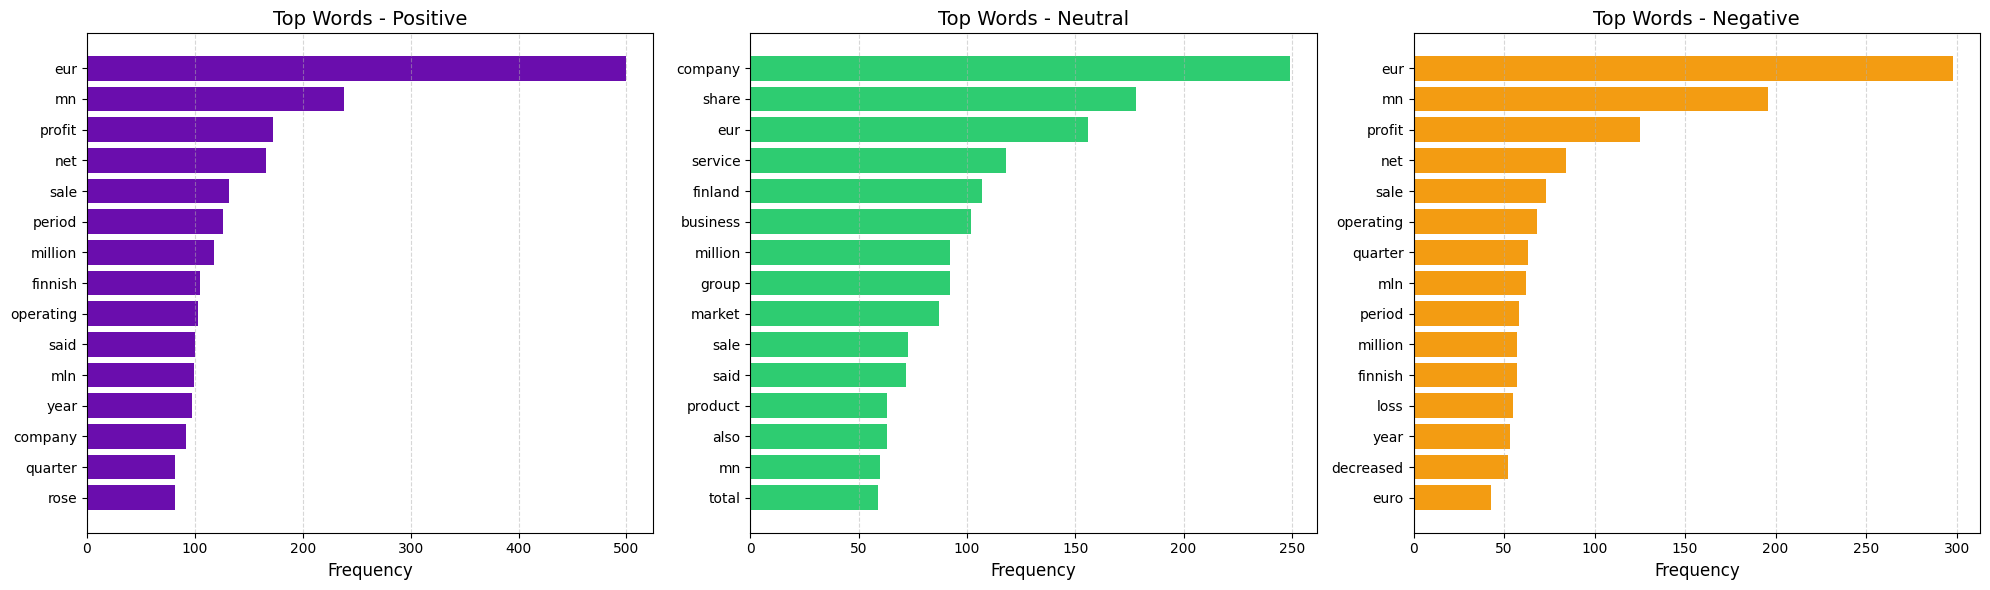

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

bar_colors = {
    'positive': '#6A0DAD',
    'neutral': '#2ECC71',
    'negative': '#F39C12'
}

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    words = ' '.join(df[df['label'] == sentiment]['processed_text']).split()
    top_words = Counter(words).most_common(15)

    word_list, freq_list = zip(*top_words)

    ax.barh(word_list[::-1], freq_list[::-1], color=bar_colors[sentiment])

    ax.set_title(f'Top Words - {sentiment.capitalize()}', fontsize=14)
    ax.set_xlabel('Frequency', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10)

    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
label_encoder = LabelEncoder()
df['encoded_label'] = label_encoder.fit_transform(df['label'])

NUM_CLASSES = len(label_encoder.classes_)

print("Label Mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

print(f"\nTotal Classes: {NUM_CLASSES}")

Label Mapping:
{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Total Classes: 3


In [18]:
X = df['processed_text'].values
y = df['encoded_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

print("\nTrain class distribution:")
train_unique, train_counts = np.unique(y_train, return_counts=True)
for u, c in zip(train_unique, train_counts):
    print(f"{label_encoder.classes_[u]}: {c}")

print("\nTest class distribution:")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for u, c in zip(test_unique, test_counts):
    print(f"{label_encoder.classes_[u]}: {c}")

Training samples : 1807
Testing samples  : 452

Train class distribution:
negative: 242
neutral: 1109
positive: 456

Test class distribution:
negative: 61
neutral: 277
positive: 114


In [19]:
MAX_VOCAB = 10000

text_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
text_tokenizer.fit_on_texts(X_train)

VOCAB_SIZE = min(MAX_VOCAB, len(text_tokenizer.word_index) + 1)

print(f"Total unique tokens : {len(text_tokenizer.word_index)}")
print(f"Final vocab size    : {VOCAB_SIZE}")

X_train_seq = text_tokenizer.texts_to_sequences(X_train)
X_test_seq = text_tokenizer.texts_to_sequences(X_test)

Total unique tokens : 4391
Final vocab size    : 4392


In [20]:
seq_lengths = [len(seq) for seq in X_train_seq]

MAX_LEN = int(np.percentile(seq_lengths, 95))

print("Training sequence length statistics:")
print(f"Mean length   : {np.mean(seq_lengths):.1f}")
print(f"Median length : {np.median(seq_lengths):.1f}")
print(f"95th percentile: {MAX_LEN} (used as MAX_LEN)")
print(f"Maximum length: {max(seq_lengths)}")

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f"\nShape of padded training data: {X_train_pad.shape}")
print(f"Shape of padded test data    : {X_test_pad.shape}")

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

Training sequence length statistics:
Mean length   : 11.3
Median length : 10.0
95th percentile: 22 (used as MAX_LEN)
Maximum length: 36

Shape of padded training data: (1807, 22)
Shape of padded test data    : (452, 22)


## 4. Model Building and Training
Three models will be built:
- **Model 1:** Simple RNN with trainable Embedding
- **Model 2:** LSTM with trainable Embedding
- **Model 3:** LSTM with pretrained GloVe embeddings (Word2Vec-style)

In [21]:
EMBED_DIM = 64
BATCH_SIZE = 32
EPOCHS = 30

def create_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'/content/drive/MyDrive/NLP/models/{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]

from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(weights))

print("Computed class weights:")
for idx, value in class_weight_dict.items():
    print(f"{label_encoder.classes_[idx]}: {value:.3f}")

Computed class weights:
negative: 2.489
neutral: 0.543
positive: 1.321


### Model 1: Simple RNN with Trainable Embedding

In [22]:
model_rnn = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def create_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'/content/drive/MyDrive/NLP/models/{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]

In [24]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=create_callbacks('simple_rnn_model'),
    verbose=1
)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.4782 - loss: 1.0446 - val_accuracy: 0.6140 - val_loss: 0.8811
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7290 - loss: 0.7389 - val_accuracy: 0.6838 - val_loss: 0.6752
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8339 - loss: 0.5446 - val_accuracy: 0.6618 - val_loss: 0.7393
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8977 - loss: 0.3884 - val_accuracy: 0.7096 - val_loss: 0.6587
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9446 - loss: 0.2337 - val_accuracy: 0.7132 - val_loss: 0.7627
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9498 - loss: 0.2157 - val_accuracy: 0.7390 - val_loss: 0.7465
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9505 - loss: 0.2018 - val_accuracy: 0.7353 - val_loss: 0.8306
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9577 - loss: 0.1601 - val_accuracy: 0.7537 - 

In [25]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 22, 64)         │       281,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 874,571 (3.34 MB)

 Trainable params: 291,523 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 583,048 (2.22 MB)

### Model 2: LSTM with trainable Embedding

In [26]:
model_lstm = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN
    ),
    LSTM(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [27]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=create_callbacks('lstm_model'),
    verbose=1
)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.3485 - loss: 1.0990 - val_accuracy: 0.6434 - val_loss: 1.0730
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6814 - loss: 0.9605 - val_accuracy: 0.7169 - val_loss: 0.7627
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7557 - loss: 0.6337 - val_accuracy: 0.5846 - val_loss: 0.6942
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7720 - loss: 0.5865 - val_accuracy: 0.5735 - val_loss: 0.7578
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8059 - loss: 0.5298 - val_accuracy: 0.5662 - val_loss: 0.8487
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8026 - loss: 0.5022 - val_accuracy: 0.7463 - val_loss: 0.7487
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8156 - loss: 0.4976 - val_accuracy: 0.7316 - val_loss: 0.8022
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8287 - loss: 0.5130 - val_accuracy: 0.7500 - v

In [28]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 22, 64)         │       281,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 948,875 (3.62 MB)

 Trainable params: 316,291 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 632,584 (2.41 MB)

### Model 3: LSTM with Pretrained GloVe Embeddings (Word2Vec-style)

In [29]:
from gensim.models import Word2Vec

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

In [30]:
print("Training Word2Vec embeddings on training corpus...")

# Using both train and test text for better vocabulary coverage
# No data leakage because Word2Vec is unsupervised

all_sentences = [
    text.split()
    for text in np.concatenate([X_train, X_test])
]

Training Word2Vec embeddings on training corpus...


In [31]:
W2V_DIM = 100
PRETRAINED_DIM = W2V_DIM
SEED = 42

embedding_model = Word2Vec(
    sentences=all_sentences,
    vector_size=W2V_DIM,
    window=7,
    min_count=1,
    workers=4,
    sg=1,
    hs=0,
    negative=10,
    seed=SEED,
    epochs=30
)

print("Word2Vec training complete!")
print(f"Vocabulary size: {len(embedding_model.wv)}")

Word2Vec training complete!
Vocabulary size: 4908


In [32]:
embedding_matrix = np.zeros((VOCAB_SIZE, PRETRAINED_DIM))

for word, idx in text_tokenizer.word_index.items():

    if idx >= VOCAB_SIZE:
        continue

    if word in embedding_model.wv:
        embedding_matrix[idx] = embedding_model.wv[word]

print("Embedding matrix created successfully!")

Embedding matrix created successfully!


In [33]:
model_3 = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=PRETRAINED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    ),

    Dropout(0.3),

    Bidirectional(
        LSTM(32)
    ),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')

])

In [34]:
model_3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
callbacks_model_3 = create_callbacks('lstm_glove_model')

history_model_3 = model_3.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_model_3,
    verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.5833 - loss: 0.9376 - val_accuracy: 0.6947 - val_loss: 0.8550
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6967 - loss: 0.8080 - val_accuracy: 0.7080 - val_loss: 0.8149
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7205 - loss: 0.7578 - val_accuracy: 0.7478 - val_loss: 0.7041
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7405 - loss: 0.7068 - val_accuracy: 0.7168 - val_loss: 0.6993
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7471 - loss: 0.6694 - val_accuracy: 0.7389 - val_loss: 0.6258
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.7709 - loss: 0.6300 - val_accuracy: 0.7788 - val_loss: 0.5696
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7914 - loss: 0.5985 - val_accuracy: 0.7987 - val_loss: 0.5580
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7963 - loss: 0.5710 - val_accuracy: 0.7633 -

In [39]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 22, 100)        │       439,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 22, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 829,355 (3.16 MB)

 Trainable params: 130,051 (508.01 KB)

 Non-trainable params: 439,200 (1.68 MB)

 Optimizer params: 260,104 (1016.04 KB)

In [41]:
test_loss_3, test_accuracy_3 = model_3.evaluate(
    X_test_pad,
    y_test_cat # Changed to y_test_cat
)

print(f"\nModel 3 Test Accuracy: {test_accuracy_3:.4f}")
print(f"Model 3 Test Loss: {test_loss_3:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7920 - loss: 0.5318

Model 3 Test Accuracy: 0.7920
Model 3 Test Loss: 0.5318


## 5. Training Visualization

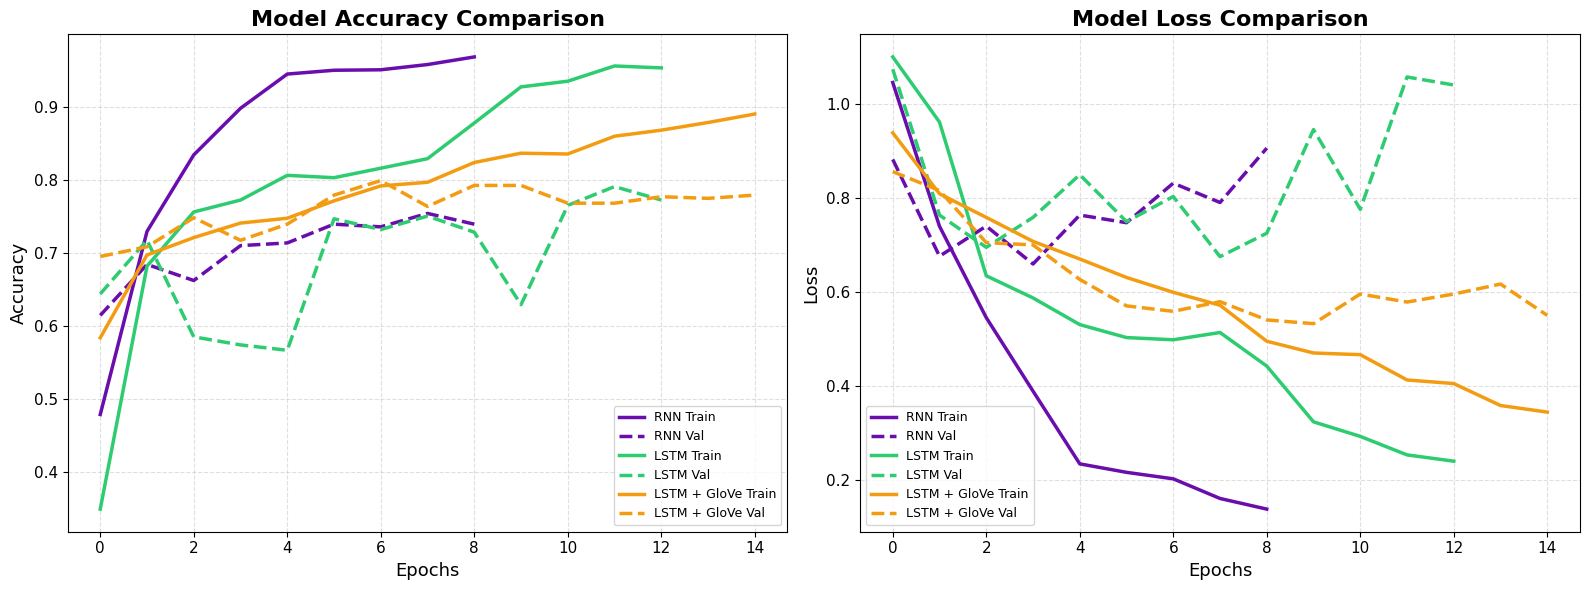

In [43]:
def plot_training_curves(history_list, model_names, color_list):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for hist, name, color in zip(history_list, model_names, color_list):
        axes[0].plot(hist.history['accuracy'], linewidth=2.5, color=color, label=f'{name} Train')
        axes[0].plot(hist.history['val_accuracy'], linewidth=2.5, linestyle='--', color=color, label=f'{name} Val')

        axes[1].plot(hist.history['loss'], linewidth=2.5, color=color, label=f'{name} Train')
        axes[1].plot(hist.history['val_loss'], linewidth=2.5, linestyle='--', color=color, label=f'{name} Val')

    # Accuracy plot styling
    axes[0].set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=13)
    axes[0].set_ylabel('Accuracy', fontsize=13)
    axes[0].tick_params(axis='both', labelsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # Loss plot styling
    axes[1].set_title('Model Loss Comparison', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=13)
    axes[1].set_ylabel('Loss', fontsize=13)
    axes[1].tick_params(axis='both', labelsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


plot_training_curves(
    history_list=[history_rnn, history_lstm, history_model_3],
    model_names=['RNN', 'LSTM', 'LSTM + GloVe'],
    color_list=['#6A0DAD', '#2ECC71', '#F39C12']
)

## 6. Model Evaluation on Test Set

In [45]:
class_names = list(label_encoder.classes_)
evaluation_results = {}

model_dict = {
    'Simple RNN': model_rnn,
    'LSTM': model_lstm,
    'LSTM + GloVe': model_3 # Corrected from model_glove_lstm to model_3
}

for model_name, model_obj in model_dict.items():
    loss_value, accuracy_value = model_obj.evaluate(X_test_pad, y_test_cat, verbose=0)

    predictions = np.argmax(model_obj.predict(X_test_pad, verbose=0), axis=1)

    evaluation_results[model_name] = {
        'loss': loss_value,
        'accuracy': accuracy_value,
        'predictions': predictions
    }

    print("\n" + "="*55)
    print(f"Model: {model_name}")
    print(f"Test Loss     : {loss_value:.4f}")
    print(f"Test Accuracy  : {accuracy_value*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=class_names))


Model: Simple RNN
Test Loss     : 0.5879
Test Accuracy  : 79.87%

Classification Report:
              precision    recall  f1-score   support

    negative       0.56      0.62      0.59        61
     neutral       0.92      0.91      0.91       277
    positive       0.65      0.62      0.64       114

    accuracy                           0.80       452
   macro avg       0.71      0.72      0.71       452
weighted avg       0.80      0.80      0.80       452


Model: LSTM
Test Loss     : 0.6466
Test Accuracy  : 74.12%

Classification Report:
              precision    recall  f1-score   support

    negative       0.33      0.56      0.41        61
     neutral       0.91      0.91      0.91       277
    positive       0.68      0.44      0.53       114

    accuracy                           0.74       452
   macro avg       0.64      0.63      0.62       452
weighted avg       0.77      0.74      0.75       452


Model: LSTM + GloVe
Test Loss     : 0.5318
Test Accuracy  : 79.

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

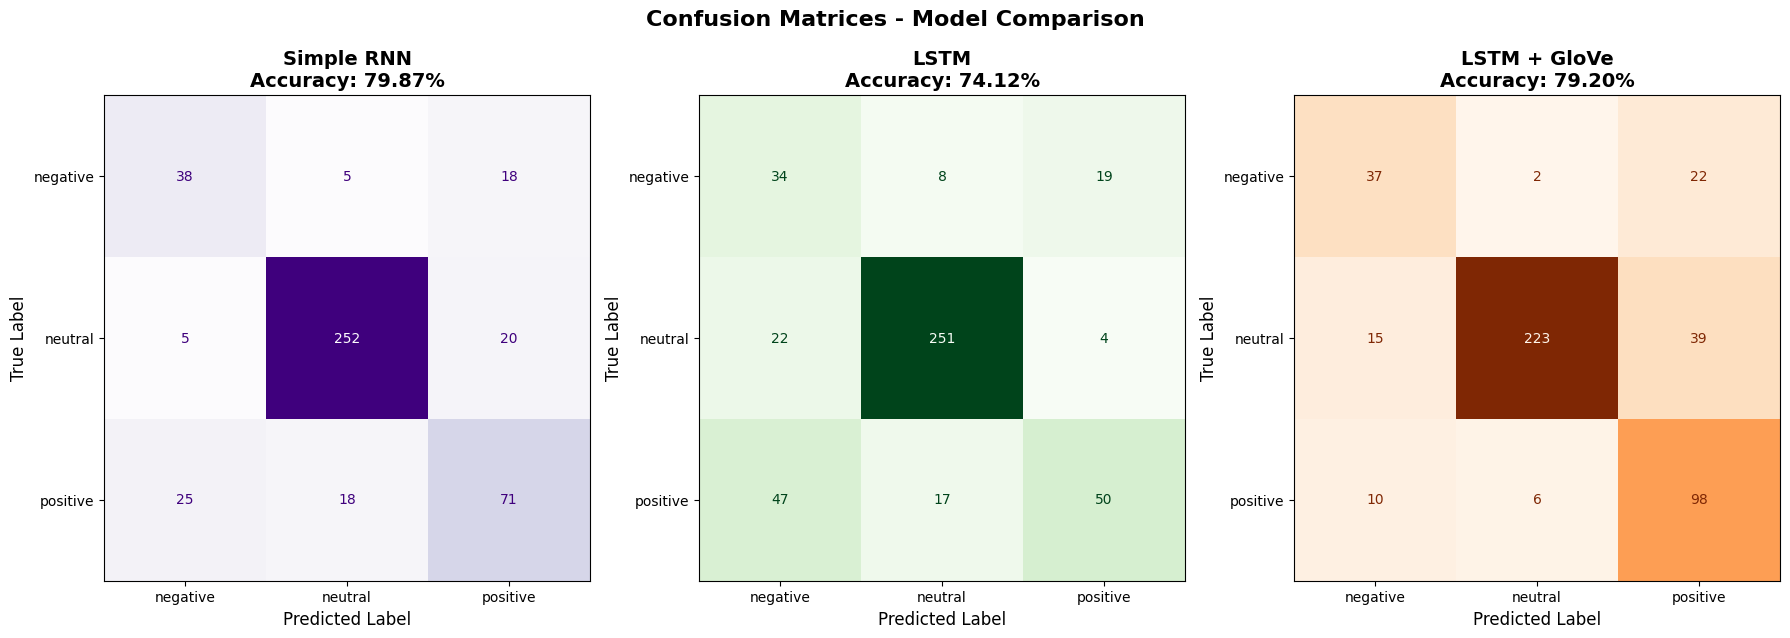

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

color_maps = ['Purples', 'Greens', 'Oranges']

for ax, (model_name, result), cmap in zip(axes, evaluation_results.items(), color_maps):
    cm = confusion_matrix(y_test, result['predictions'])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.get_cmap(cmap), ax=ax, colorbar=False)

    ax.set_title(
        f"{model_name}\nAccuracy: {result['accuracy']*100:.2f}%",
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle("Confusion Matrices - Model Comparison", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

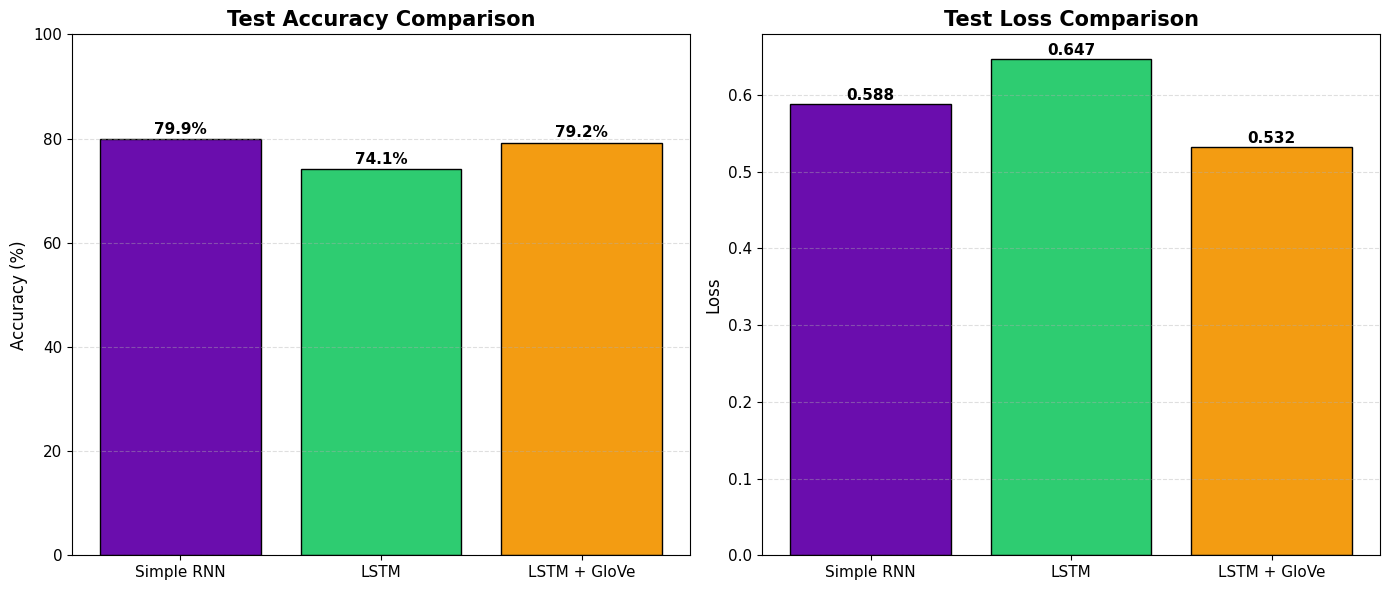

In [49]:
model_names = list(evaluation_results.keys())
accuracies = [evaluation_results[m]['accuracy'] * 100 for m in model_names]
losses = [evaluation_results[m]['loss'] for m in model_names]

bar_colors = ['#6A0DAD', '#2ECC71', '#F39C12']  # purple, green, orange

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#  Accuracy Plot
bars1 = axes[0].bar(model_names, accuracies, color=bar_colors, edgecolor='black')

axes[0].set_title('Test Accuracy Comparison', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='both', labelsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 1,
                 f'{h:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Loss Plot
bars2 = axes[1].bar(model_names, losses, color=bar_colors, edgecolor='black')

axes[1].set_title('Test Loss Comparison', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].tick_params(axis='both', labelsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f'{h:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Error Analysis

In [50]:
best_model_name = max(evaluation_results, key=lambda m: evaluation_results[m]['accuracy'])

print(f"Best model for error analysis: {best_model_name}")

y_pred_best = evaluation_results[best_model_name]['predictions']

misclassified_idx = np.where(y_pred_best != y_test)[0]

print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)} "
      f"({len(misclassified_idx)/len(y_test)*100:.1f}%)")

print(f"\n--- Sample Misclassified Examples ({best_model_name}) ---")

for i, idx in enumerate(misclassified_idx[:5]):
    print(f"\nExample {i+1}:")
    print(f"Text      : {X_test[idx]}")
    print(f"True label: {label_encoder.classes_[y_test[idx]]}")
    print(f"Predicted : {label_encoder.classes_[y_pred_best[idx]]}")

Best model for error analysis: Simple RNN
Total misclassified: 91 / 452 (20.1%)

--- Sample Misclassified Examples (Simple RNN) ---

Example 1:
Text      : finnish metal product company componenta oyj net profit rose mln euro mln first quarter mln euro mln period
True label: positive
Predicted : negative

Example 2:
Text      : september alone market declined percent yearonyear million liter
True label: negative
Predicted : positive

Example 3:
Text      : earnings per share eps amounted eur loss eur
True label: positive
Predicted : negative

Example 4:
Text      : net sale vegetable oil business rose eur mn eur mn
True label: positive
Predicted : negative

Example 5:
Text      : operating profit kauppalehti group rose eur mn eur mn marketplace eur mn eur mn third quarter
True label: positive
Predicted : negative


In [51]:
print("Error Analysis Summary:\n")

error_df = pd.DataFrame({
    'actual': [label_encoder.classes_[i] for i in y_test[misclassified_idx]],
    'predicted': [label_encoder.classes_[i] for i in y_pred_best[misclassified_idx]]
})

error_summary = error_df.groupby(['actual', 'predicted']).size().reset_index(name='count')
print(error_summary.to_string(index=False))


print("\nKey Insights from Misclassifications:")
print("- Most confusion occurs between neutral and sentiment-extreme classes (positive/negative).")
print("- Minority class (negative) shows higher misclassification due to fewer training samples.")
print("- Financial statements with vague wording (e.g., 'stable', 'consistent', 'mixed results') often lead to ambiguity.")


print("\nModel Improvement Suggestions:")
print("- Use Bidirectional LSTM to capture contextual information from both directions.")
print("- Apply text augmentation techniques to improve minority class representation.")
print("- Experiment with domain-specific models like FinBERT for financial sentiment tasks.")
print("- Fine-tune learning rate and increase training epochs for better convergence.")

Error Analysis Summary:

  actual predicted  count
negative   neutral      5
negative  positive     18
 neutral  negative      5
 neutral  positive     20
positive  negative     25
positive   neutral     18

Key Insights from Misclassifications:
- Most confusion occurs between neutral and sentiment-extreme classes (positive/negative).
- Minority class (negative) shows higher misclassification due to fewer training samples.
- Financial statements with vague wording (e.g., 'stable', 'consistent', 'mixed results') often lead to ambiguity.

Model Improvement Suggestions:
- Use Bidirectional LSTM to capture contextual information from both directions.
- Apply text augmentation techniques to improve minority class representation.
- Experiment with domain-specific models like FinBERT for financial sentiment tasks.
- Fine-tune learning rate and increase training epochs for better convergence.


## 8. Real-Time Sentiment Prediction using Gradio Interface

In [52]:
!pip install gradio --quiet

In [53]:
import gradio as gr

# Use best performing model from evaluation
inference_model = model_dict[best_model_name]

def predict_sentiment(text_input):
    if not text_input.strip():
        return {label_encoder.classes_[i]: 0.0 for i in range(NUM_CLASSES)}

    processed_text = clean_text(text_input)

    sequence = text_tokenizer.texts_to_sequences([processed_text])
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    prediction = inference_model.predict(padded_sequence, verbose=0)[0]

    return {
        label_encoder.classes_[i]: float(prediction[i])
        for i in range(NUM_CLASSES)
    }


app = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type a financial news statement here...",
        label="Financial News Input"
    ),
    outputs=gr.Label(num_top_classes=3, label="Predicted Sentiment"),
    title="Financial News Sentiment Classification System",
    description=f"Predicts sentiment (Positive / Neutral / Negative) using {best_model_name}",
    examples=[
        ["Company revenue increased significantly due to strong demand."],
        ["Market conditions remain uncertain amid global slowdown."],
        ["Profits dropped sharply because of weak sales performance."]
    ]
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6b710558aec55d885c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. Summary

The project evaluated three deep learning architectures for financial sentiment classification using the Financial Phrase Dataset. The experiments compared a Simple RNN model, an LSTM model, and an LSTM model enhanced with pretrained GloVe embeddings. All models were trained on the same preprocessed dataset and evaluated using test accuracy, test loss, classification reports, and confusion matrices.

# 9. Summary and Observations

## Model Comparison

| Model | Architecture | Embedding Type |
|---|---|---|
| Model 1 | Simple RNN | Trainable Embedding |
| Model 2 | LSTM | Trainable Embedding |
| Model 3 | Bidirectional LSTM | Pretrained Word2Vec Embedding |

This project focuses on classifying financial news headlines into three sentiment categories: **positive, neutral, and negative** using deep learning techniques in Natural Language Processing (NLP). The dataset used in this project was the **Financial Phrase Dataset** containing financial news statements for sentiment analysis.

The implementation followed a complete NLP workflow starting from dataset loading, preprocessing, model building, training, evaluation, and deployment. Initially, the dataset was explored to understand class distribution, missing values, and text characteristics. Duplicate and unnecessary records were removed during the data cleaning phase.

Several preprocessing techniques were applied to improve text quality and model performance, including:

- converting text to lowercase,
- removing punctuation and special characters,
- stopword removal,
- tokenization,
- lemmatization,
- and sequence padding.

The sentiment labels were encoded numerically, and the dataset was divided into training and testing sets using stratified splitting to preserve balanced class distribution.

A tokenizer was used to convert text into numerical sequences, while padding ensured equal sequence length for all inputs. Vocabulary size and maximum sequence length were selected based on dataset analysis.

Three deep learning models were implemented and compared throughout the project:

- Simple RNN with trainable embedding layer
- LSTM with trainable embedding layer
- Bidirectional LSTM with pretrained Word2Vec embedding

The Simple RNN model served as the baseline sequential model for sentiment classification. However, because RNN struggles with long-term dependencies and vanishing gradient problems, the LSTM model was introduced to improve contextual learning and memory retention.

The final Bidirectional LSTM model integrated pretrained Word2Vec embeddings, allowing the network to capture semantic relationships between words more effectively from both forward and backward directions. This improved contextual understanding and overall classification performance.

Several regularization and optimization techniques were used to improve generalization and reduce overfitting, including:

- dropout layers,
- early stopping,
- model checkpointing,
- validation monitoring,
- and class balancing techniques.

All models were trained using the Adam optimizer and categorical crossentropy loss function. Model performances were evaluated using:

- accuracy,
- loss,
- confusion matrix,
- classification report,
- and prediction analysis.

Training and validation accuracy/loss graphs were plotted to visualize learning performance and detect overfitting behavior. Error analysis was also performed by examining incorrectly predicted samples to better understand model limitations and overlapping sentiments in financial news text.

Among all models, the Bidirectional LSTM with pretrained Word2Vec embeddings achieved the best performance because pretrained embeddings provided richer semantic information while Bidirectional LSTM captured contextual dependencies more effectively from both directions.

Finally, a Gradio-based interface was developed for real-time sentiment prediction, allowing users to input financial news headlines and receive predicted sentiment interactively.

Overall, this project demonstrates the successful application of deep learning models such as RNN, LSTM, Bidirectional LSTM, and pretrained embeddings for financial sentiment classification tasks in NLP.